# **Caso 3 – People Analytics: Engagement**

**Objetivo del análisis**

La compañía quiere entender:

- Qué factores explican el nivel de engagement.
- Si el salario es realmente determinante.
- Si existen momentos críticos en el ciclo de vida del empleado.
- Si el engagement impacta en el performance.

** Hipótesis a contrastar**

1. El liderazgo (Manager Rating) es el principal driver.
2. Work-Life Balance tiene impacto significativo.
3. El salario tiene impacto limitado.
4. Existe un "valle" de engagement entre 2–4 años.
5. Mayor engagement implica mejor performance.

El objetivo final es traducir los resultados en decisiones estratégicas de HR.

In [21]:
# Importamos las librerias que vamos a usar

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [22]:
# Cargamos el dataset

employees = pd.read_csv("https://raw.githubusercontent.com/Pablolg87/people-analytics-case-03-employee-engagement/refs/heads/main/engagement_people_analytics_case.csv")

# Visualizamos primeras filas
employees.head()

,Engagement_Score,Manager_Rating,Work_Life_Balance,Salary_Increase_%,Training_Hours,Promotion,Remote,Tenure_Years,Department,Performance_Rating
0,91.9,4.5,4.1,5.0,17.0,0,1,6,Operations,4.6
1,68.0,3.5,1.9,2.4,11.0,1,1,3,Sales,4.2
2,86.9,4.0,3.4,2.9,0.0,0,1,7,Tech,4.5
3,66.5,3.3,4.0,4.4,13.0,1,1,4,Tech,4.0
4,82.0,3.8,3.3,3.8,18.0,0,0,6,Sales,5.0


# Diccionario de variables – Caso Engagement

A continuación se describen las variables incluidas en el análisis:


**Engagement_Score**  
Puntuación global de compromiso del empleado (30–100).  
Es la variable principal del estudio.  
Por debajo de 60 se considera bajo engagement; por encima de 75, alto.

**Manager_Rating**  
Valoración del manager directo (1–5).  
Mide la percepción del liderazgo. Se espera que sea un factor clave.

**Work_Life_Balance**  
Percepción del equilibrio vida-trabajo (1–5).  
Evalúa cómo el empleado percibe su carga y conciliación.

**Salary_Increase_%**  
Incremento salarial anual (0–15%).  
Se analizará si realmente influye en el compromiso.

**Training_Hours**  
Horas de formación recibidas en el último año (0–60).  
Permite evaluar el impacto del desarrollo profesional.

**Promotion**  
Indica si el empleado ha sido promocionado (0 = no, 1 = sí).

**Remote**  
Modalidad de trabajo (0 = presencial, 1 = remoto/híbrido).

**Tenure_Years**  
Años de antigüedad en la empresa (0–9).  
Se analizará si existen momentos críticos en el ciclo de vida.

**Department**  
Área a la que pertenece el empleado (Tech, Sales, HR, Operations).

**Performance_Rating**  
Evaluación anual de desempeño (1–5).  
Se utilizará para comprobar si mayor engagement se relaciona con mejor rendimiento.

**EDA PRELIMINAR**

In [23]:
# Tamaño del dataset

employees.shape

(500, 10)

In [24]:
# Información general

employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Engagement_Score    500 non-null    float64
 1   Manager_Rating      500 non-null    float64
 2   Work_Life_Balance   500 non-null    float64
 3   Salary_Increase_%   500 non-null    float64
 4   Training_Hours      500 non-null    float64
 5   Promotion           500 non-null    int64  
 6   Remote              500 non-null    int64  
 7   Tenure_Years        500 non-null    int64  
 8   Department          500 non-null    object 
 9   Performance_Rating  500 non-null    float64
dtypes: float64(6), int64(3), object(1)
memory usage: 39.2+ KB


In [25]:
# Valores estadísticos básicos

employees.describe()

,Engagement_Score,Manager_Rating,Work_Life_Balance,Salary_Increase_%,Training_Hours,Promotion,Remote,Tenure_Years,Performance_Rating
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,78.114600,3.478800,3.301000,5.128800,20.114000,0.188000,0.582000,4.430000,4.308400
std,11.771346,0.767573,0.872802,1.989544,9.598608,0.391103,0.493724,2.941156,0.433896
min,38.000000,1.300000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,71.075000,2.900000,2.700000,3.800000,14.000000,0.000000,0.000000,2.000000,4.000000
50%,78.800000,3.500000,3.300000,5.100000,20.000000,0.000000,1.000000,4.000000,4.300000
75%,86.700000,4.000000,3.900000,6.500000,26.250000,0.000000,1.000000,7.000000,4.600000
max,100.000000,5.000000,5.000000,11.400000,51.000000,1.000000,1.000000,9.000000,5.000000


In [26]:
# Comprobación de valores nulos

employees.isnull().sum()

,0
Engagement_Score,0
Manager_Rating,0
Work_Life_Balance,0
Salary_Increase_%,0
Training_Hours,0
Promotion,0
Remote,0
Tenure_Years,0
Department,0
Performance_Rating,0


In [27]:
# Comprobamos duplicados

employees.duplicated().sum()

np.int64(0)

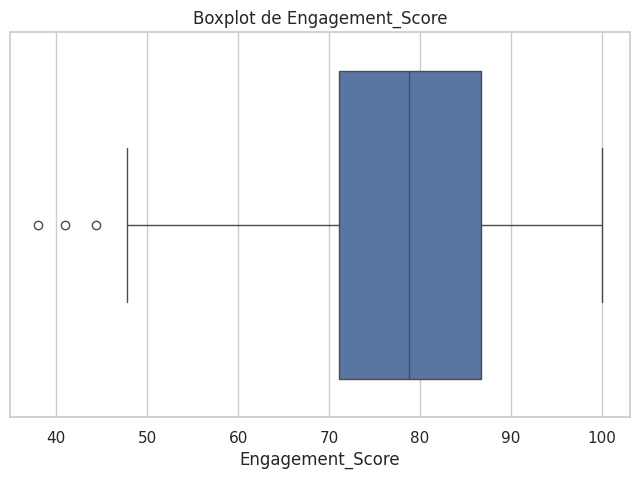

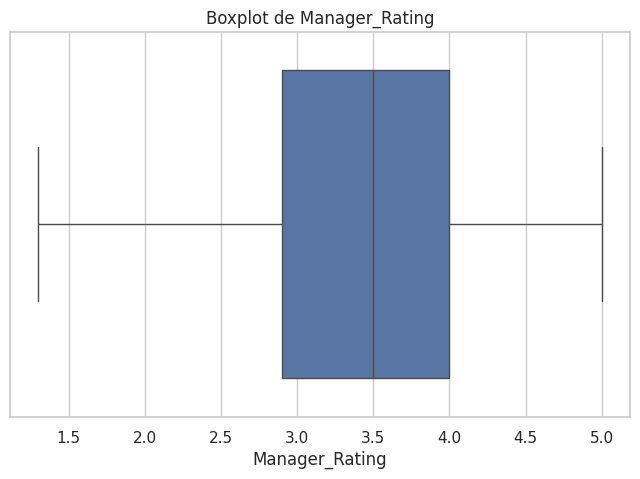

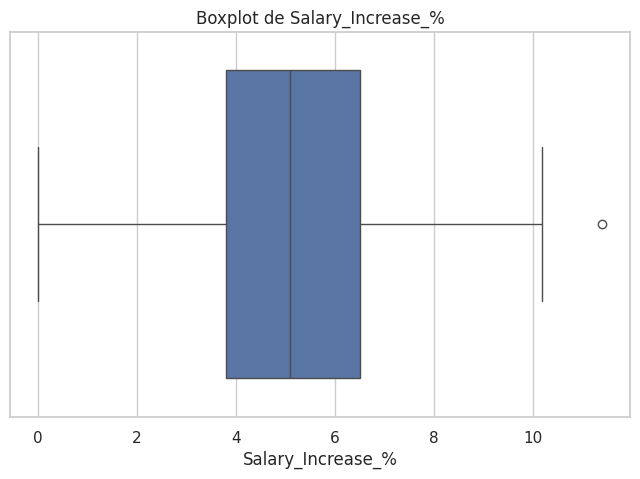

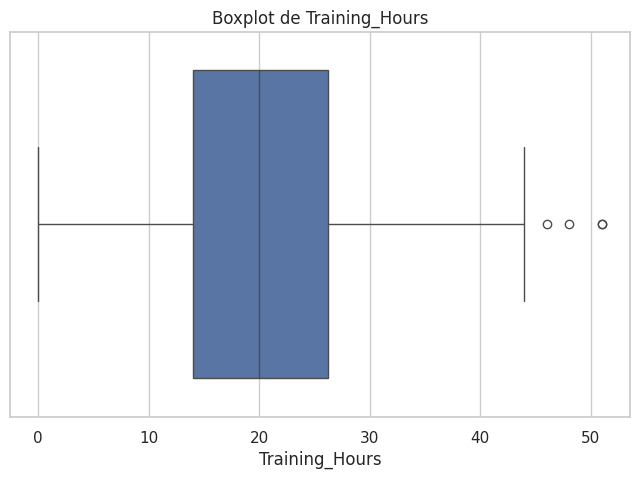

In [28]:
# Detección de Outliers

numeric_cols = ["Engagement_Score",
                "Manager_Rating",
                "Salary_Increase_%",
                "Training_Hours"]

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=employees[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

**Revisión de variables y outliers**

Se han revisado las principales variables numéricas para detectar valores anómalos.

Manager_Rating está dentro del rango esperado (1 a 5) y no presenta valores extraños.
Salary_Increase_% se concentra principalmente entre el 4% y el 7%, con algunos casos puntuales más altos que son coherentes.

Training_Hours muestra más variación, con algunos empleados superando las 40 horas, algo razonable según el perfil.

En general, no se detectan errores ni problemas en los datos.

Los valores extremos representan situaciones reales, por lo que se mantienen para el análisis.

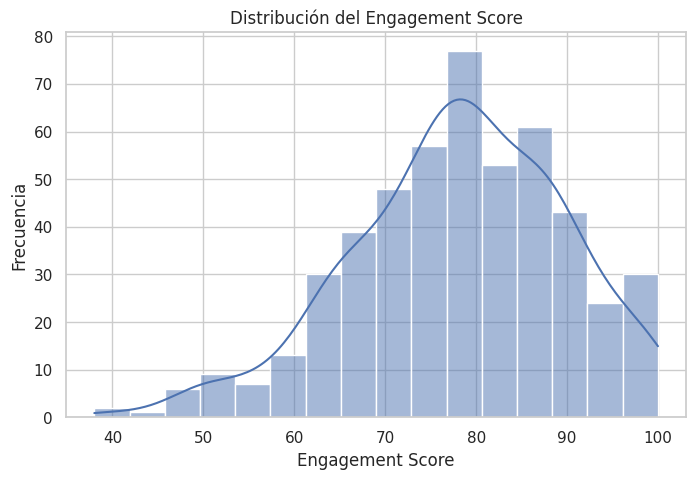

In [29]:
# DIDistribución de Engagement

plt.figure()
sns.histplot(employees["Engagement_Score"], kde=True)
plt.title("Distribución del Engagement Score")
plt.xlabel("Engagement Score")
plt.ylabel("Frecuencia")
plt.show()

La mayoría de los empleados tienen un nivel de engagement entre 70 y 90 puntos, con una media alrededor de 80. En general, el compromiso en la empresa es bueno.

Hay algunos casos por debajo de 50 puntos. Son pocos, pero importantes, ya que representan empleados claramente desmotivados.

No se observan concentraciones extrañas ni valores extremos que distorsionen el análisis, por lo que la variable es adecuada para trabajar con ella.

A nivel de negocio, el problema no parece ser un bajo engagement general, sino entender por qué algunos empleados están más comprometidos que otros.

In [30]:
# Media de Engage por departamento


employees.groupby("Department")["Engagement_Score"].mean().sort_values(ascending=False)

,Engagement_Score
Department,
Operations,80.074444
Sales,78.812805
Tech,77.420000
HR,75.601515


# Engagement medio por departamento

Operations es el área con mayor nivel medio de engagement (80), seguida de Sales (78.8) y Tech (77.4).  
HR es la que presenta el nivel más bajo (75.6).

Las diferencias no son muy grandes, pero sí muestran que el compromiso no es igual en toda la empresa.

Esto indica que puede haber factores internos en cada área que estén influyendo en cómo se sienten los empleados.

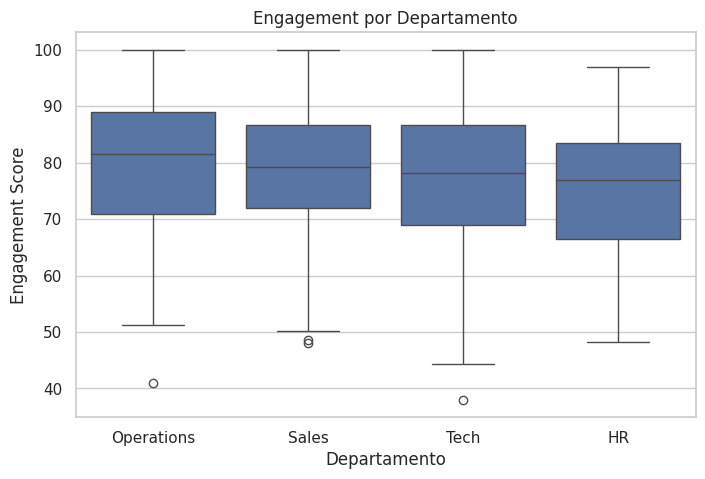

In [31]:
# Engagement por departamento (distribución, no solo media)

plt.figure()
sns.boxplot(data=employees, x="Department", y="Engagement_Score")
plt.title("Engagement por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Engagement Score")
plt.show()

# Qué nos aporta este gráfico (Engagement por departamento)

Aunque las medias por departamento son parecidas, el boxplot muestra diferencias internas.

- **Operations** tiene la mediana más alta (la mayoría está alrededor de 80+) pero aparece algún caso aislado con engagement muy bajo.
- **Sales** se mantiene bastante estable: la mayoría está entre ~70 y ~87, con pocos casos bajos.
- **Tech** es el departamento con más variabilidad: hay más dispersión y aparecen los valores más bajos del gráfico (casos puntuales por debajo de 40–45). Esto sugiere “bolsas” de bajo engagement dentro del área.
- **HR** tiene la mediana más baja y un rango amplio, lo que indica un nivel algo más débil y menos homogéneo.

En resumen: no parece un problema “global” por departamento, sino que hay áreas (sobre todo **Tech**) donde conviene segmentar y entender qué está pasando en los grupos con engagement bajo.

**Correlaciones entre variables**

In [32]:
# Correlación de variables numéricas con Engagement

corr = employees.select_dtypes(include="number").corr()["Engagement_Score"].sort_values(ascending=False)

corr

,Engagement_Score
Engagement_Score,1.000000
Performance_Rating,0.752198
Manager_Rating,0.644617
Work_Life_Balance,0.436095
Training_Hours,0.273275
Promotion,0.155150
Remote,0.136669
Tenure_Years,0.104808
Salary_Increase_%,0.031200


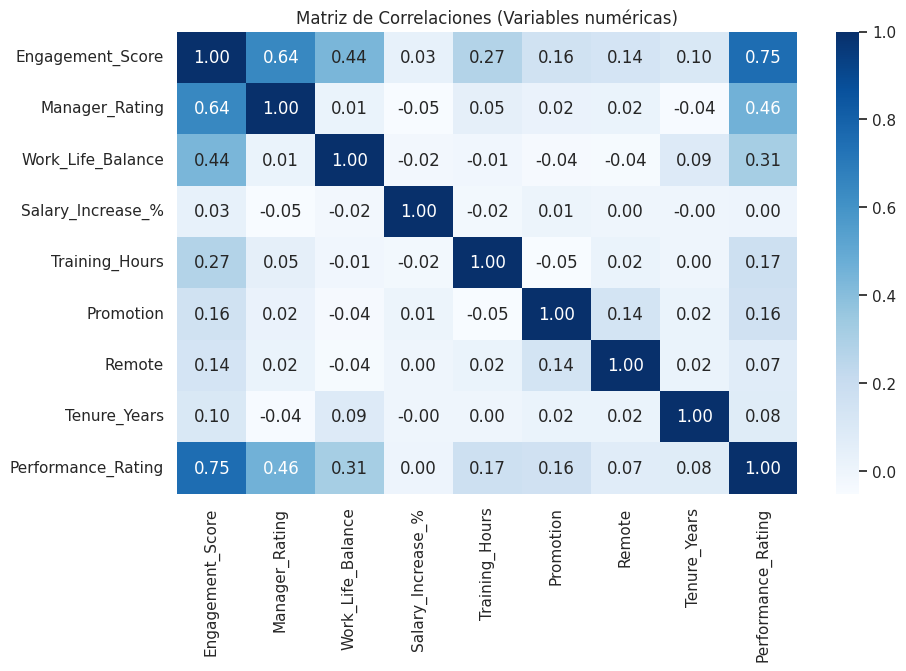

In [33]:
# Heatmap de correlaciones

plt.figure(figsize=(10,6))
sns.heatmap(employees.select_dtypes(include="number").corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de Correlaciones (Variables numéricas)")
plt.show()

# Lectura rápida del heatmap

A partir de la matriz de correlaciones, podemos identificar qué variables están más asociadas con el nivel de engagement.

Las variables que muestran una relación más fuerte con el Engagement_Score son:

- **Manager_Rating** → Es la variable más relacionada. A mejor valoración del manager, mayor engagement.
- **Work_Life_Balance** → También presenta una relación clara. Mejor equilibrio, mayor compromiso.
- **Training_Hours** → Relación positiva moderada. Más formación, mayor engagement.
- **Performance_Rating** → Relación positiva. El engagement y el rendimiento tienden a ir de la mano.

En cambio, variables como:

- **Salary_Increase_%**
- **Remote**
- **Promotion**

muestran una relación más débil con el engagement.

Esto sugiere que el compromiso no está impulsado principalmente por factores económicos, sino por liderazgo, experiencia diaria y desarrollo profesional

**Ahora veremos el engagement según las variables que se correlacionan más:**

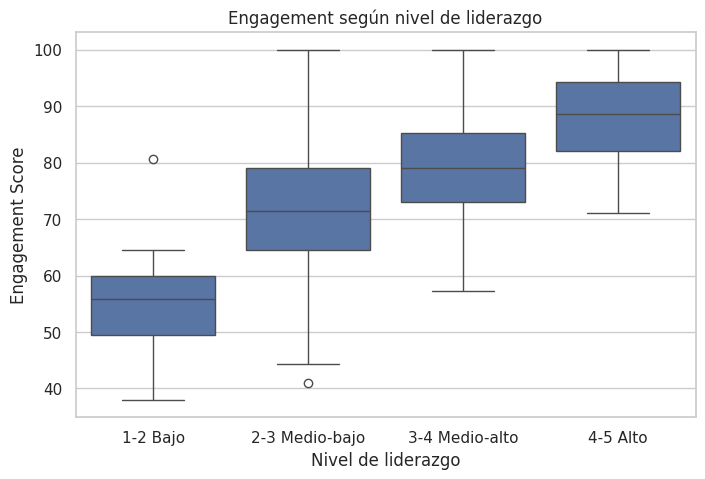

In [34]:
# Engagement según valoración del manager

# Creamos tramos de liderazgo
employees["Manager_Group"] = pd.cut(
    employees["Manager_Rating"],
    bins=[1,2,3,4,5],
    labels=["1-2 Bajo", "2-3 Medio-bajo", "3-4 Medio-alto", "4-5 Alto"]
)

plt.figure(figsize=(8,5))
sns.boxplot(data=employees,
            x="Manager_Group",
            y="Engagement_Score")

plt.title("Engagement según nivel de liderazgo")
plt.xlabel("Nivel de liderazgo")
plt.ylabel("Engagement Score")
plt.show()

# Engagement según nivel de liderazgo

El gráfico muestra una relación muy clara entre liderazgo y engagement.

Cuando el nivel de liderazgo es bajo (1–2), el engagement se sitúa mayoritariamente entre 50 y 60 puntos.

En niveles medios (2–3 y 3–4), el engagement aumenta de forma progresiva y se mueve ya en rangos de 70–80.

Cuando el liderazgo es alto (4–5), el engagement supera claramente los 85 puntos en la mayoría de los casos.

La relación es consistente y escalonada: a mejor liderazgo, mayor compromiso.

Esto confirma que el manager es uno de los principales factores que explican el engagement en la organización.

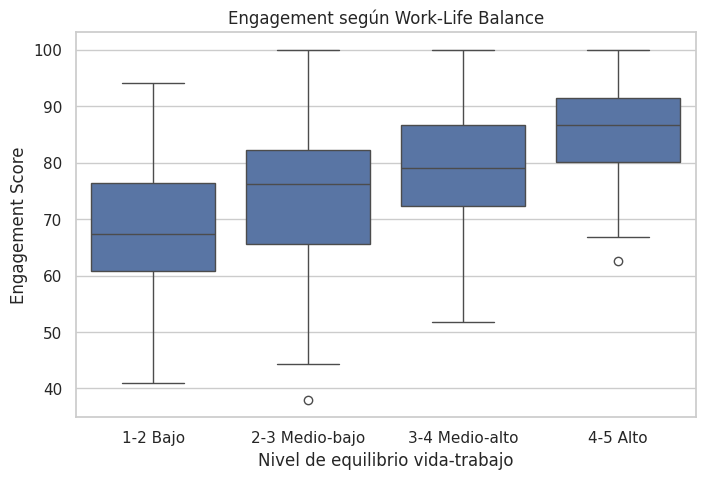

In [35]:
# Agrupamos Work_Life_Balance en tramos

employees["WLB_Group"] = pd.cut(
    employees["Work_Life_Balance"],
    bins=[1,2,3,4,5],
    labels=["1-2 Bajo", "2-3 Medio-bajo", "3-4 Medio-alto", "4-5 Alto"]
)

plt.figure(figsize=(8,5))
sns.boxplot(data=employees,
            x="WLB_Group",
            y="Engagement_Score")

plt.title("Engagement según Work-Life Balance")
plt.xlabel("Nivel de equilibrio vida-trabajo")
plt.ylabel("Engagement Score")
plt.show()

# Engagement y Work-Life Balance

El gráfico muestra una relación clara y progresiva entre el equilibrio vida-trabajo y el engagement.

Cuando el equilibrio es bajo (1–2), el engagement se sitúa mayoritariamente en torno a 60–70 puntos.

En niveles medios (2–3 y 3–4), el engagement aumenta y se mueve alrededor de 75–80.

Cuando el equilibrio es alto (4–5), el engagement supera de forma consistente los 85 puntos.

La tendencia es estable y creciente: a mejor percepción del equilibrio, mayor compromiso.

Aunque el impacto es ligeramente menor que el del liderazgo, el equilibrio vida-trabajo aparece como un factor relevante en el engagement.

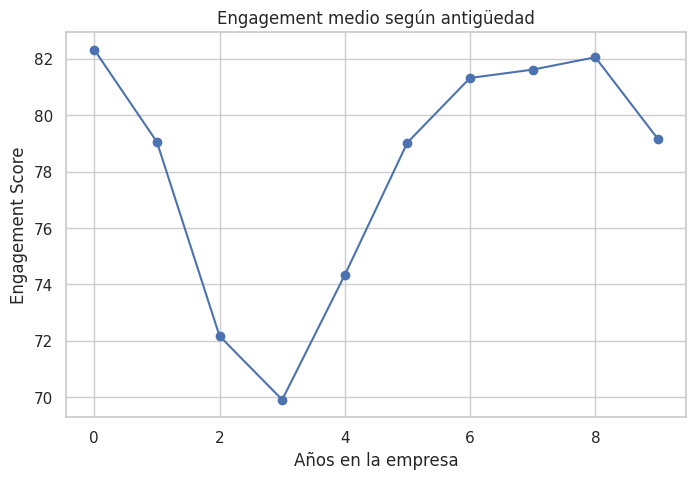

,Engagement_Score
Tenure_Years,
0,82.316129
1,79.046341
2,72.168421
3,69.910417
4,74.334694
5,79.028205
6,81.316364
7,81.611765
8,82.050000


In [36]:
# Engagement medio por año de antigüedad

tenure_avg = employees.groupby("Tenure_Years")["Engagement_Score"].mean()

plt.figure(figsize=(8,5))
tenure_avg.plot(marker="o")
plt.title("Engagement medio según antigüedad")
plt.xlabel("Años en la empresa")
plt.ylabel("Engagement Score")
plt.grid(True)
plt.show()

tenure_avg

# Engagement y antigüedad

El gráfico muestra un patrón claro en forma de “valle”.

El engagement es alto en el primer año, pero cae de forma notable entre el segundo y tercer año, alcanzando su punto más bajo alrededor del año 3.

A partir del cuarto año, el engagement vuelve a recuperarse progresivamente y se estabiliza en niveles altos.

Esto sugiere un momento crítico en el ciclo de vida del empleado entre los 2 y 4 años.
Puede coincidir con expectativas de crecimiento, desarrollo o reconocimiento que no siempre se cumplen.

Desde el punto de vista de gestión, este tramo es clave para diseñar planes de desarrollo y evitar desmotivación o rotación.

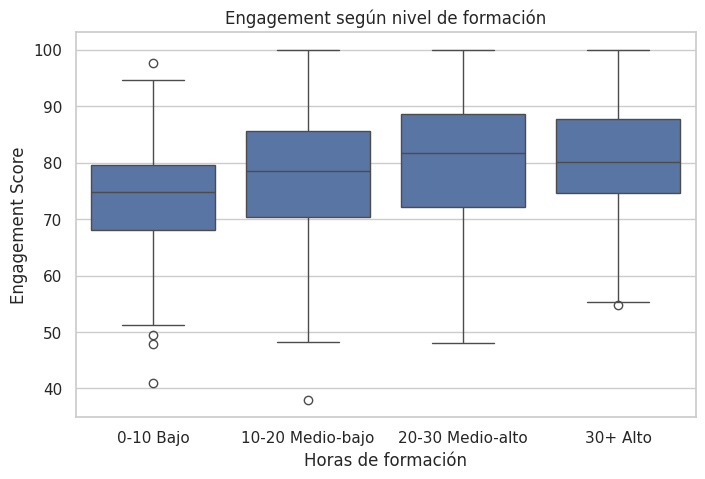

In [37]:
# Agrupamos las horas de formación en tramos

employees["Training_Group"] = pd.cut(
    employees["Training_Hours"],
    bins=[0,10,20,30,60],
    labels=["0-10 Bajo", "10-20 Medio-bajo", "20-30 Medio-alto", "30+ Alto"]
)

plt.figure(figsize=(8,5))
sns.boxplot(data=employees,
            x="Training_Group",
            y="Engagement_Score")

plt.title("Engagement según nivel de formación")
plt.xlabel("Horas de formación")
plt.ylabel("Engagement Score")
plt.show()

# Engagement y formación

El gráfico muestra una tendencia positiva entre formación y engagement.

Los empleados con menos horas de formación (0–10) presentan niveles de engagement más bajos en comparación con el resto.

A medida que aumentan las horas de formación (10–20 y 20–30), el engagement medio también aumenta de forma progresiva.

En el tramo de 30+ horas, el engagement se mantiene en niveles altos y más estables.

Aunque el impacto no es tan fuerte como el del liderazgo, la formación aparece como una palanca clara para reforzar el compromiso.

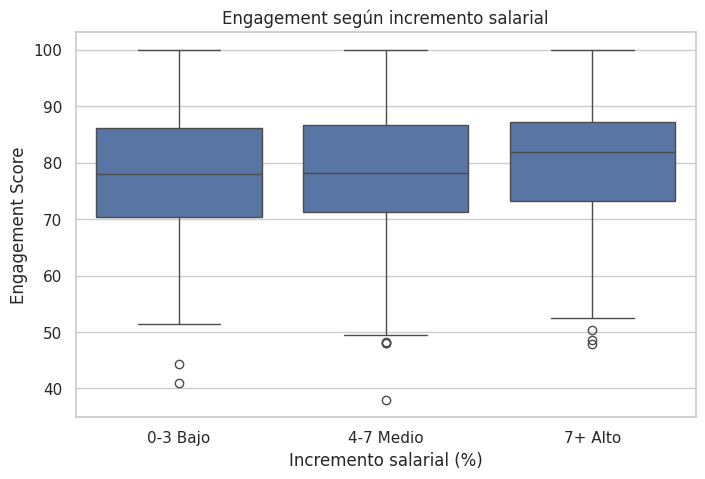

In [38]:
# Agrupamos el incremento salarial en tramos

employees["Salary_Group"] = pd.cut(
    employees["Salary_Increase_%"],
    bins=[0,3,7,15],
    labels=["0-3 Bajo", "4-7 Medio", "7+ Alto"]
)

plt.figure(figsize=(8,5))
sns.boxplot(data=employees,
            x="Salary_Group",
            y="Engagement_Score")

plt.title("Engagement según incremento salarial")
plt.xlabel("Incremento salarial (%)")
plt.ylabel("Engagement Score")
plt.show()

# Engagement y salario

Las diferencias entre los distintos niveles de incremento salarial son pequeñas.

El grupo con incrementos altos (7%+) muestra un engagement ligeramente superior, pero la distancia respecto a los otros grupos no es grande.

Además, en los tres tramos aparecen casos de bajo engagement, lo que indica que un mayor incremento salarial no garantiza automáticamente mayor compromiso.

En comparación con liderazgo o equilibrio vida-trabajo, el impacto del salario es claramente menor.

Esto refuerza la idea de que el engagement está más relacionado con la experiencia diaria y el desarrollo que con la compensación económica.

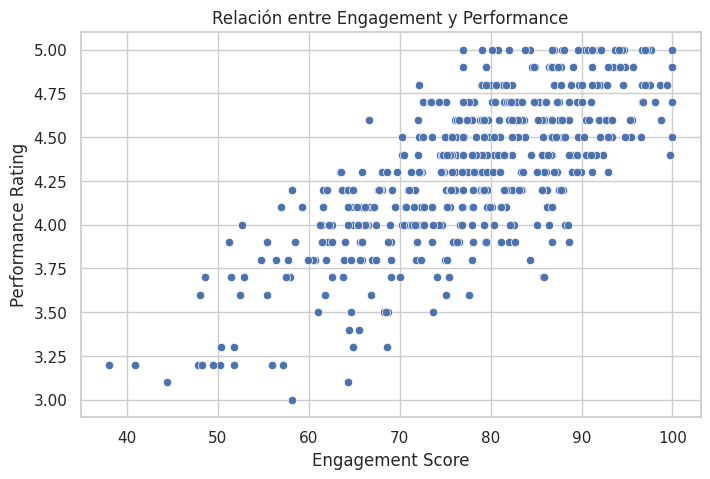

In [39]:
# Relación entre Engagement y Performance

plt.figure(figsize=(8,5))
sns.scatterplot(data=employees,
                x="Engagement_Score",
                y="Performance_Rating")

plt.title("Relación entre Engagement y Performance")
plt.xlabel("Engagement Score")
plt.ylabel("Performance Rating")
plt.show()

In [40]:
# Correlación entre Engagement y Performance

employees[["Engagement_Score", "Performance_Rating"]].corr()

,Engagement_Score,Performance_Rating
Engagement_Score,1.000000,0.752198
Performance_Rating,0.752198,1.000000


# Engagement y rendimiento

El gráfico muestra una relación claramente positiva entre engagement y performance.

A medida que aumenta el Engagement Score, también aumenta la valoración de desempeño. Los empleados con engagement por encima de 80 puntos tienden a situarse en niveles de performance cercanos a 4.5–5.

La correlación es de 0.75, lo que indica una relación fuerte. No es perfecta, pero sí lo suficientemente elevada como para afirmar que el engagement está claramente vinculado al rendimiento.

En términos de negocio, esto confirma que mejorar el engagement no es solo una cuestión de clima interno, sino una palanca directa de mejora del desempeño.

# Conclusiones Teoricas

## 1. Qué explica el engagement

El análisis muestra que el engagement está principalmente relacionado con:

- **Calidad del liderazgo** → Es el factor con mayor impacto.
- **Equilibrio vida-trabajo** → Influencia clara y consistente.
- **Formación y desarrollo** → Impacto positivo moderado.
- **Antigüedad** → Existe un momento crítico entre los 2 y 4 años.

En cambio, el **incremento salarial** presenta un impacto limitado en comparación con los factores anteriores.


## 2. Momento crítico en el ciclo de vida

Se observa un “valle” de engagement entre el segundo y tercer año en la empresa.

Esto sugiere la necesidad de reforzar:
- Planes de desarrollo
- Conversaciones de carrera
- Programas de reconocimiento

especialmente en ese tramo temporal.


## 3. Engagement y rendimiento

La correlación entre engagement y performance es de 0.75, lo que indica una relación fuerte.

Los empleados con mayor engagement tienden a mostrar mejores evaluaciones de desempeño.

Esto confirma que el engagement no es solo una métrica de clima, sino una variable directamente vinculada a resultados de negocio.

## 4. Implicaciones estratégicas

Si el objetivo es mejorar el rendimiento organizativo, las palancas más eficaces no son únicamente salariales.

Las intervenciones deberían centrarse en:

- Desarrollo de liderazgo
- Mejora del equilibrio vida-trabajo
- Planes estructurados de formación
- Gestión del ciclo de vida del empleado


## 5. Conclusión general

El engagement en esta organización no depende principalmente de la compensación económica, sino de la experiencia diaria del empleado.

Invertir en liderazgo y desarrollo tiene un impacto directo tanto en el compromiso como en el rendimiento.

# **IMPACTO EN NEGOCIO**

Para traducir el análisis a valor de negocio, se realiza u**na estimación del impacto económico asociado a bajos niveles de engagement.**

Este enfoque parte de una hipótesis sencilla:
*los empleados con bajo engagement tienden a tener menor performance, lo que implica una pérdida de productividad.*

Si la compañía implementa acciones específicas de HR (liderazgo, workload, experiencia del empleado), **parte de ese gap de performance podría recuperarse.**

**El objetivo** no es obtener una cifra exacta, sino **dimensionar el orden de magnitud del impacto económico.**

In [44]:
# Vamos a identificar el grupo con bajo Engagement

# Definimos el umbral de bajo engagement como el percentil 25
# Es decir, el 25% de empleados con menor engagement
low_eng_threshold = employees["Engagement_Score"].quantile(0.25)

# Filtramos los empleados que están por debajo de ese umbral
# Este será el grupo objetivo para análisis y posibles acciones de HR
low_eng_group = employees[employees["Engagement_Score"] <= low_eng_threshold].copy()

# Calculamos métricas clave del grupo
num_low_eng = len(low_eng_group)  # número de empleados en bajo engagement
avg_eng_low = low_eng_group["Engagement_Score"].mean()  # engagement medio del grupo
avg_perf_low = low_eng_group["Performance_Rating"].mean()  # performance medio del grupo

# Calculamos el performance medio total de la compañía
avg_perf_total = employees["Performance_Rating"].mean()

# Mostramos resultados
print(f"Empleados con bajo engagement: {num_low_eng}")
print(f"Engagement medio (grupo bajo): {avg_eng_low:.2f}")
print(f"Performance medio (grupo bajo): {avg_perf_low:.2f}")
print(f"Performance medio (empresa): {avg_perf_total:.2f}")

Empleados con bajo engagement: 125
Engagement medio (grupo bajo): 62.48
Performance medio (grupo bajo): 3.85
Performance medio (empresa): 4.31


In [45]:
# Calculamos la diferencia entre el performance medio de la empresa
# y el performance del grupo de bajo engagement
performance_gap = avg_perf_total - avg_perf_low

# Nos aseguramos de que el gap no sea negativo (por robustez del cálculo)
performance_gap = max(performance_gap, 0)

# Mostramos el gap de performance
print(f"Gap de performance vs media: {performance_gap:.2f} puntos")

Gap de performance vs media: 0.45 puntos


**Supuesto económico utilizado**

Dado que el dataset no incluye salario absoluto, se utiliza un salario medio estimado de 40.000 € anuales como proxy del valor económico del empleado.

Esta cifra permite construir una estimación sencilla del impacto potencial del bajo engagement en términos de productividad recuperable.

In [48]:
# Como el dataset no incluye salario absoluto, usamos un salario medio estimado
# como proxy del valor económico del empleado.
# Este supuesto permite dimensionar el impacto en negocio de forma sencilla.
base_salary = 40000

# Definimos hipótesis de negocio simples y explicables:
recovery_rate = 0.30       # % del gap de performance que la empresa podría recuperar
productivity_weight = 0.50 # % del salario aproximado como valor productivo

# Convertimos el gap de performance en impacto económico estimado:
# - número de empleados con bajo engagement
# - salario medio estimado como proxy de valor
# - peso de productividad
# - porcentaje del gap recuperable
estimated_savings = (
    num_low_eng
    * base_salary
    * productivity_weight
    * (performance_gap / 100)  # convertimos el gap a proporción
    * recovery_rate
)

# Mostramos el resultado final
print(f"Ahorro anual estimado: €{estimated_savings:,.0f}")

Ahorro anual estimado: €3,405


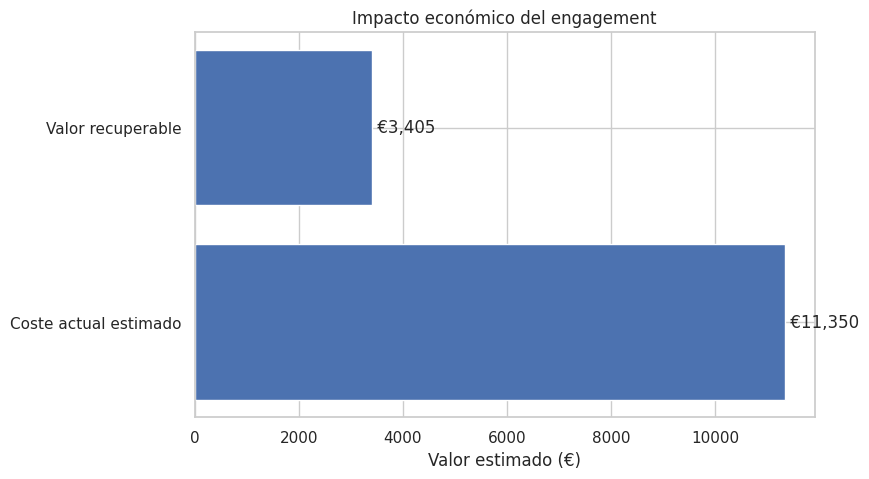

In [49]:
# Calculamos escenario actual (coste total estimado sin intervención)
current_cost = estimated_savings / recovery_rate

# Escenario mejorado (lo que se puede recuperar)
recovered_value = estimated_savings

labels = ["Coste actual estimado", "Valor recuperable"]
values = [current_cost, recovered_value]

plt.figure()

plt.barh(labels, values)

plt.title("Impacto económico del engagement")

# Añadimos etiquetas con €
for i, v in enumerate(values):
    plt.text(v, i, f" €{v:,.0f}", va='center')

plt.xlabel("Valor estimado (€)")

plt.show()

# **Conclusión**

El análisis muestra que **el engagement no es solo una métrica de HR, sino una variable con impacto directo en el rendimiento organizativo**.

Los empleados con menor engagement presentan un gap de performance relevante, lo que se traduce en una pérdida de productividad.

**Actuar sobre los principales drivers identificado**s (liderazgo, work-life balance, experiencia del empleado) **permite recuperar parte de ese valor, generando un impacto económico tangible.**

Este enfoque permite a HR tomar decisiones más estratégicas, basadas en datos y alineadas con objetivos de negocio.